In [55]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [56]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [57]:
_dataset = datasets.ImageFolder(root='./datasets/chest_xray/train', transform=transforms.ToTensor())
_loader  = DataLoader(_dataset)

mean   = torch.zeros(3)
sq_mean = torch.zeros(3)
n_pixels = 0

with torch.no_grad():
    for images, _ in _loader:
        b, c, h, w = images.shape
        n_pixels += b * h * w
        mean     += images.sum(dim=[0, 2, 3])
        sq_mean  += (images ** 2).sum(dim=[0, 2, 3])

mean  /= n_pixels
std    = (sq_mean / n_pixels - mean ** 2).sqrt()

MEAN = tuple(round(float(i), 4) for i in mean)
STD  = tuple(round(float(i), 4) for i in std)

MEAN, STD

((0.4875, 0.4875, 0.4875), (0.2456, 0.2456, 0.2456))

In [58]:
train_transform = transforms.Compose([
    # Data Augmentation: 학습 데이터를 인위적으로 변경하여 다양성을 높인다.
    transforms.Resize((256, 256)),

    # 상하좌우 32px zero-padding 후 256×256 랜덤 크롭, 물체 위치가 조금씩 달라진다.
    # transforms.RandomCrop(256, padding=32),

    # 50% 확률로 좌우 반전
    # transforms.RandomHorizontalFlip(),
    
    # 밝기 및 대비 ±20% 랜덤 변화
    # transforms.ColorJitter(brightness=0.2, contrast=0.2),

    # PIL Image, Numpy array -> PyTorch Tensor
    transforms.ToTensor(),
    
    # 채널별 정규화: (pixel - mean) / std
    transforms.Normalize(MEAN, STD),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((256, 256)),
    transforms.Normalize(MEAN, STD),
])

In [59]:
# ImageFolder로 train, test 폴더 내부 class 폴더 자동 인식
train_dataset = datasets.ImageFolder(root='./datasets/chest_xray/train', transform=train_transform)
test_dataset  = datasets.ImageFolder(root='./datasets/chest_xray/test',  transform=test_transform)

# DataLoader로 dataset을 mini-batch 단위로 묶어서 제공
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False)

print(train_dataset.classes)
print(train_dataset.class_to_idx)

['NORMAL', 'PNEUMONIA']
{'NORMAL': 0, 'PNEUMONIA': 1}


In [60]:
print(len(train_dataset))
print(len(test_dataset))

5232
624


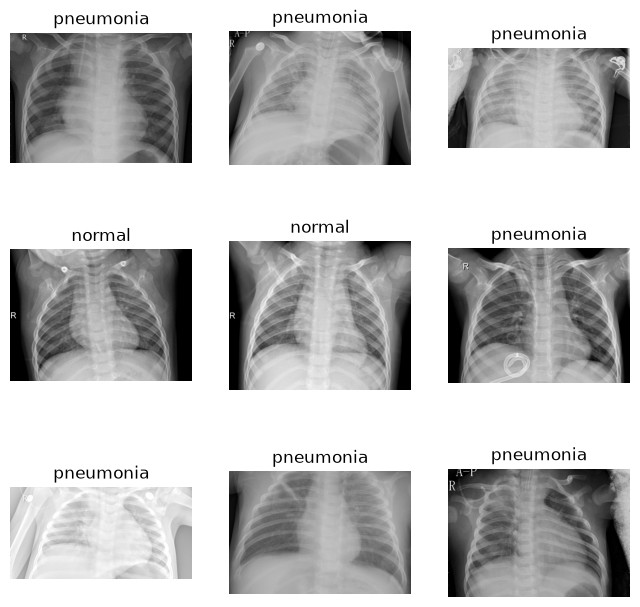

In [61]:
labels = {
  0: 'normal',
  1: 'pneumonia'
}

pre = datasets.ImageFolder(root='./datasets/chest_xray/train', transform=transforms.ToTensor())

figure = plt.figure(figsize=(8, 8))
for i in range(1, 10):
  idx = torch.randint(len(pre), size=(1, )).item()
  img, label = pre[idx]
  figure.add_subplot(3, 3, i)
  plt.title(labels[label])
  plt.axis('off')
  plt.imshow(img.permute(1, 2, 0))

plt.show()

In [62]:
# CNN 학습 class 정의
# Convolution layer + MaxPooling -> Fully-Connected Layer

class CNN(nn.Module):  # nn.Module: PyTorch 신경망 모듈 base class 상속
    def __init__(self):
        super().__init__()  # nn.Module 생성자 호출
        self.features = nn.Sequential(
            # Layer 1
            nn.Conv2d(3, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            
            nn.Conv2d(64, 64, 3, padding=1, bias=False),  # 이전 feature map에서 동일한 channel size로 더 자세한 패턴 학습
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 256×256 → 128×128

            # Layer 2
            nn.Conv2d(64, 128, 3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            
            nn.Conv2d(128, 128, 3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 128×128 → 64×64

            # Layer 3
            nn.Conv2d(128, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            
            nn.Conv2d(256, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)  # 64×64 → 32×32
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(256, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),  # training 중 무작위로 50%의 뉴런 비활성화, 과적합 방지를 위한 정규화 기법
            nn.Linear(256, 10)
        )

    def forward(self, x):  # nn.Module forward() overriding
        return self.classifier(self.features(x))

model = CNN().to(device)

In [63]:
criterion = nn.CrossEntropyLoss()  # CrossEntropyLoss function
optimizer = optim.Adam(model.parameters(), lr=0.0007)  # Adam optimizer, learning rate: 0.0007

In [64]:
train_losses, test_losses         = [], []
train_accuracies, test_accuracies = [], []

In [65]:
epochs = 30

for epoch in range(epochs):

    # ── Train ──
    model.train()  # 모델 학습 진행
    running_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()  # loss값을 통해 현재 기울기를 계산하여 파라미터 값을 .grad에 저장
        optimizer.step() # .grad 값을 기반으로 최적의 파라미터 계산 후 가중치 업데이트
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc  = 100 * correct / total

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    # ── Test ──
    model.eval()  # 모델 추론 진행
    correct_test, total_test, test_loss = 0, 0, 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            test_loss += loss.item()
            
            _, predicted = torch.max(outputs, 1)
            
            total_test += labels.size(0)
            correct_test += (predicted == labels).sum().item()

    test_loss = test_loss / len(test_loader)
    test_acc = 100 * correct_test / total_test

    test_losses.append(test_loss)
    test_accuracies.append(test_acc)

    print(f"Epoch [{epoch+1}/{epochs}] "
          f"Train Loss: {train_loss:.4f} | "
          f"Test Loss: {test_loss:.4f} | "
          f"Train Acc: {train_acc:.2f}% | "
          f"Test Acc: {test_acc:.2f}%")

Epoch [1/30] Train Loss: 0.4047 | Test Loss: 0.4082 | Train Acc: 84.56% | Test Acc: 83.81%
Epoch [2/30] Train Loss: 0.1979 | Test Loss: 1.5476 | Train Acc: 92.11% | Test Acc: 66.51%
Epoch [3/30] Train Loss: 0.1750 | Test Loss: 0.6467 | Train Acc: 93.48% | Test Acc: 79.65%
Epoch [4/30] Train Loss: 0.1429 | Test Loss: 0.4592 | Train Acc: 94.48% | Test Acc: 83.81%
Epoch [5/30] Train Loss: 0.1326 | Test Loss: 0.3893 | Train Acc: 95.18% | Test Acc: 83.81%
Epoch [6/30] Train Loss: 0.1211 | Test Loss: 0.8222 | Train Acc: 95.78% | Test Acc: 75.80%
Epoch [7/30] Train Loss: 0.1103 | Test Loss: 0.3557 | Train Acc: 95.83% | Test Acc: 86.86%
Epoch [8/30] Train Loss: 0.1138 | Test Loss: 0.8255 | Train Acc: 95.76% | Test Acc: 77.40%
Epoch [9/30] Train Loss: 0.1095 | Test Loss: 0.4667 | Train Acc: 95.85% | Test Acc: 82.37%
Epoch [10/30] Train Loss: 0.0921 | Test Loss: 0.7810 | Train Acc: 96.60% | Test Acc: 78.04%
Epoch [11/30] Train Loss: 0.0843 | Test Loss: 0.6388 | Train Acc: 96.75% | Test Acc: 79.1

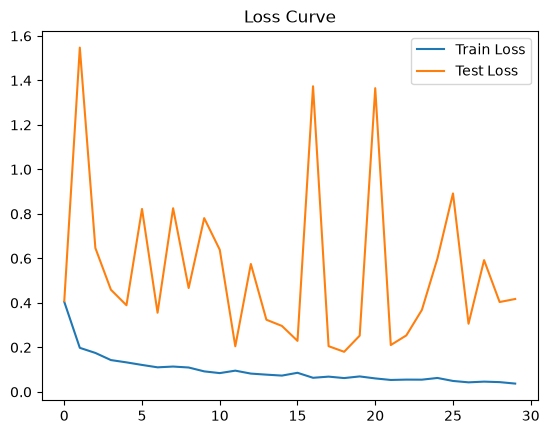

In [66]:
plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.legend()
plt.title("Loss Curve")
plt.show()

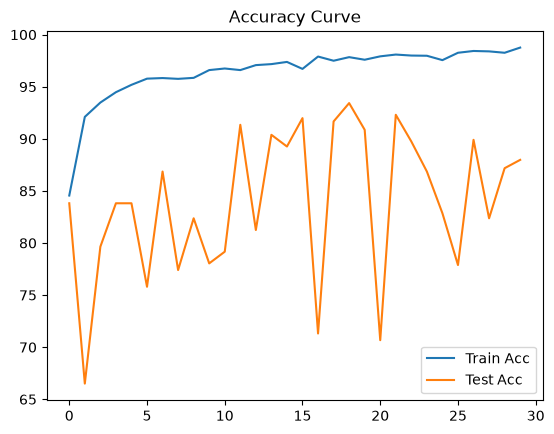

In [67]:
plt.figure()
plt.plot(train_accuracies, label="Train Acc")
plt.plot(test_accuracies, label="Test Acc")
plt.legend()
plt.title("Accuracy Curve")
plt.show()

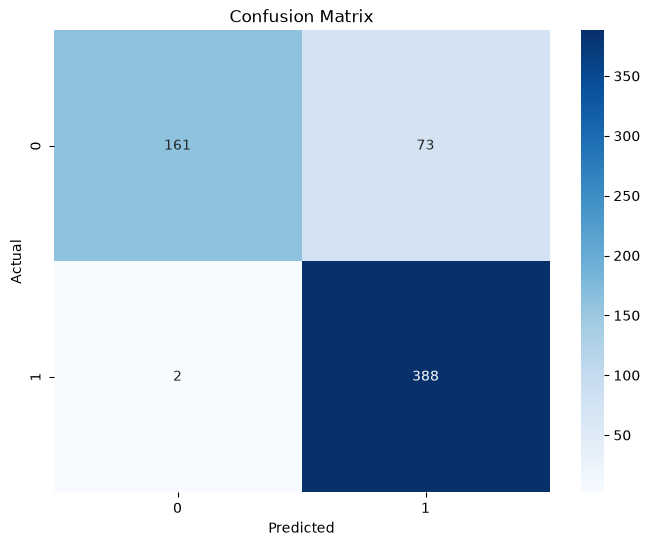

In [68]:
all_preds = []
all_labels = []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

 
cm = confusion_matrix(all_labels, all_preds)

# 🔹 Plot
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

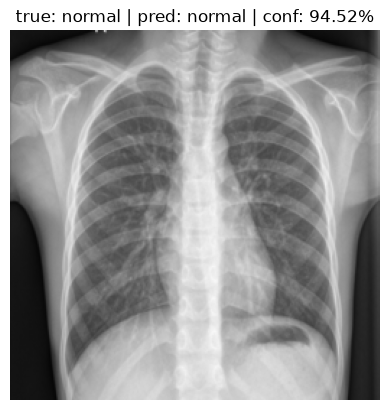

In [100]:
CLASSES = ("normal", "pneumonia")
MEAN = torch.tensor(list(round(float(i), 4) for i in mean)).view(3,1,1)
STD  = torch.tensor(list(round(float(i), 4) for i in std)).view(3,1,1)

images, labels = next(iter(test_loader))

idx = 1
single_image = images[idx].unsqueeze(0)
true_label   = labels[idx].item()

with torch.no_grad():
    output      = model(single_image.to(device))
    probs       = torch.softmax(output, dim=1)
    pred_label  = torch.argmax(probs, dim=1).item()
    confidence  = probs[0][pred_label].item()

# 역정규화(denormalize): Normalize 적용 전 원본 픽셀값으로 복원
img = images[idx] * STD + MEAN
img = img.permute(1, 2, 0).clamp(0, 1)  # clamp: 역정규화 후 범위를 [0,1]로 보정

plt.imshow(img)
plt.title(f"true: {CLASSES[true_label]} | pred: {CLASSES[pred_label]} | conf: {confidence:.2%}")
plt.axis('off')
plt.show()